# 物体運動のシミュレーション

### ● 発展編 ― 垂直抗力と摩擦

宇都宮大学　吉田勝俊

**学習内容**

1. はじめに ― 地面や壁を作りたい！
1. 垂直抗力 $R$
1. 摩擦力 $F$
1. 接触力 $\fimp$
1. 研究課題


***
※ Python では，必要な機能を「インポート」して使います．

In [ ]:
import numpy as np                              #数値計算機能のインポート 別名np
import matplotlib.pyplot as plt                 #グラフ描画機能のインポート 別名plt
from scipy.integrate import odeint              #常微分方程式の数値解法をインポート
from matplotlib.animation import FuncAnimation  #アニメーション機能のインポート
from matplotlib import rc                       #各種設定機能のインポート
rc('animation', html='jshtml')                  #Colabでアニメーション表示可能にするための設定

テキストセルで使う LaTeX マクロ（学術論文で使われる数式入力法）

- $\newcommand{\fimp}{f^{\mathrm{\Delta}}} \fimp$
$\newcommand{\sign}{\mathrel{\mathrm{sign}}} \sign$


## §１ はじめに ― 地面や壁を作りたい！

### ● 前提

追加したい効果は，運動方程式に追加するしかない　＝　数式を追加するしかない

### ● 地面や壁を表す数式は，外力項に作り込む！


地面や壁に接触した瞬間だけ，外力 $f$ に接触力 $\fimp$ を代入する．

$m x''(t) = f =
\begin{cases}
\fimp & \text{接触状態} \\
0 & \text{それ以外} \\
\end{cases}
$

※（質量）×（加速度）＝（外力）

| | |
| ------ | ------ |
| $m$  | 質量 |
| $x(t)$  | 運動（位置の時間変化） |
| $f$  | 外力 |

どのような数式で，$\fimp$ を表すか？

## §２ 垂直抗力 $R$

### ● 定義

接触した面から物体が受ける，面に垂直な力のこと．

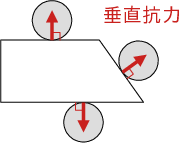

### ● 垂直抗力の数理モデル（トランポリン型）

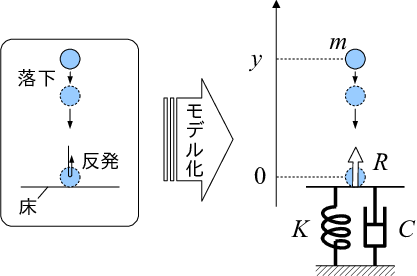

$\displaystyle
R = R(y,y') =
\begin{cases}
- K y - Cy' & (y < 0) \;\text{※接触状態}\\
0 & (y \geq 0) \;\text{※それ以外}\\
\end{cases}
$

## §３ 摩擦力 $F$

### ● 定義

摩擦面から物体が受ける，摩擦速度 $v$ と逆向きの力のこと．

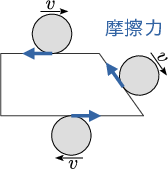

### ● 摩擦力の数理モデル（クーロン摩擦）

クーロン摩擦力　＝　摩擦係数 × 垂直抗力　※摩擦速度 $v$ と逆向き

$F = F(v) =
\begin{cases}
\mu R & (v < 0) \\
0 & (v=0)\\
-\mu R & (v > 0) \\
\end{cases}
$

場合分けを分離して，次のように書き直す．

$F = F(v) =
-\mu R \sign(v),\quad
\sign(v) =
\begin{cases}
-1 & (v < 0) \\
0 & (v=0)\\
1 & (v > 0) \\
\end{cases}
$

$\sign$ を符号関数という．

$\sign$ 関数は，場合分けのままだと，正負が激しく切り替わり，数値計算が不安定になる．<br/>そこで，角を丸めるためシグモイド関数という関数を使う．

In [ ]:
def sign(v, s):
    """
    符号関数の定義（角を丸めたバージョン）
    """
    sigmoid_range = 34.538776394910684
    sv = np.clip(s*v, -sigmoid_range, sigmoid_range)

    return 1.0 / (1.0 + np.exp(-sv))

$s$ を大きくすると，場合分けに近づく．

In [ ]:
vs = np.linspace(-1, 1, 1000)

signs = sign(vs, s=5)
plt.plot(vs, signs, label=r'$s=5$')
signs = sign(vs, s=10)
plt.plot(vs, signs, label=r'$s=10$')
signs = sign(vs, s=10000)
plt.plot(vs, signs, label=r'$s=10000$')

plt.xlabel(r'$v$')
plt.ylabel(r'$sign(v)$')
plt.legend()
plt.grid()

## §４ 接触力 $\fimp$

$\boldsymbol\fimp =
\begin{bmatrix}
F(x') \\
R(y,y')
\end{bmatrix}
\begin{array}{l}
\text{面成分（摩擦力）} \\
\text{垂直成分（垂直抗力）}
\end{array}
=
\begin{bmatrix}
-\mu R \sign(x') \\
\begin{cases}
- K y - Cy' & (y < 0) \\
0 & (y \geq 0)\\
\end{cases}
\end{bmatrix}
$

> #### **実習１**
>
> 接触力の面成分 $F$ と，垂直成分 $R$ の矢印を，下図に描き込め．
>
> 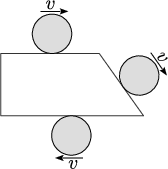

## §５ 床に衝突する自由落下物体（垂直運動のみ）

### ● 運動方程式

$\displaystyle
m x'' = F(x') = -\mu R(y,y')\sign(x'),
$

$\displaystyle
m y'' = -mg + R(y,y'),\quad
R(y,y') =
\begin{cases}
- K y - Cy' & (y < 0) \;\text{※接触状態}\\
0 & (y \geq 0) \;\text{※それ以外}\\
\end{cases}
$

基礎編「§４ 大気中の質点の放物運動」と同様に，速度 $x'$, $y'$ を別の変数 $v$, $w$ で書くと，次のように書き直せる．

$\begin{cases}
x' = v, \\
\displaystyle
v' = -\frac{\mu}{m} R(y,w)\sign(v),\\
y' = w,
\\ \displaystyle
w'= - g + \frac{1}{m}R(y,w),
\end{cases}
\quad (v = x',\;w = y')
$

**導出：**

- 第1式，第3式は，変数の定義 $v=x'$，$w=y'$ そのもの．
- 第2式は，$x$ の運動方程式<br/>
$\displaystyle
mx''= m(x')' = mv' = -\mu R(y,y')\sign(x') = -\mu R(y,w)\sign(v)
$<br/>の両辺を，$m$ で割ったもの．
- 第4式は，$y$ の運動方程式<br/>
$\displaystyle
my''= m(y')' = mw' = -mg + R(y,y') = -mg + R(y,w)
$<br/>の両辺を，$m$ で割ったもの．

### ● 運動方程式の数値解法

In [ ]:
def R(y, w, K, C):
    """
    垂直抗力の数式表現（トランポリン型）
    """
    if y < 0:
        R = -K*y - C*w
    else:
        R = 0

    return R

In [ ]:
def Bouncing(xvyw, t, K, C, mu):
    '''
    床に衝突する自由落下物体の運動方程式（垂直運動のみ）
    '''
    x, v, y, w = xvyw   # 垂直変位と速度

    m = 1       # 物体の質量
    g = 9.8     # 重力加速度

    s = 10000   # 符号関数の丸め

    # 運動方程式(1回微分に書き直した)
    dxdt = v
    dvdt = -(mu/m)*R(y, w, K, C)*sign(v, s)
    dydt = w
    dwdt = -g + (1/m)*R(y, w, K, C)

    return [dxdt, dvdt, dydt, dwdt] #４式をまとめて返す

In [ ]:
K = 8000    # 床のバネ定数
C = 25      # 床の減衰係数
mu = 0.04   # 床の摩擦係数

x0 = 0      # x方向の初期位置〔m〕
v0 = 2      # x方向の初速度〔m/s〕
y0 = 3      # y方向の初期位置〔m〕
w0 = 0      # y方向の初速度〔m/s〕

t = np.linspace(0, 6, 200)  # 時間軸
xvywt = odeint(Bouncing, [x0, v0, y0, w0], t, args=(K,C,mu)) # 運動方程式を解く

xt = xvywt[:,0] # x 方向の位置〔m〕
vt = xvywt[:,1] # x 方向の速度〔m/s〕
yt = xvywt[:,2] # y 方向の位置〔m〕
wt = xvywt[:,3] # y 方向の速度〔m/s〕

### ● 数値解のグラフ表示

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(6.4, 4.8))

ax[0].plot(t, xt)
ax[0].set_ylabel(r'$x(t)$')
ax[1].plot(t, vt)
ax[1].set_ylabel(r'$v(t)$')
ax[2].plot(t, yt)
ax[2].set_ylabel(r'$y(t)$')
ax[3].plot(t, wt)
ax[3].set_ylabel(r'$w(t)$')
ax[3].set_xlabel(r'$t$')
for a in ax: a.grid()
fig.tight_layout()

### ● 数値解のアニメーション表示

In [ ]:
def animate_Bouncing(xt, yt):
  '''
  数値解をアニメーション表示する
  '''
  # グラフ用紙の設定
  # fig グラフ用紙
  # ax  座標軸
  fig, ax= plt.subplots(1, 1, figsize=(8,4)) #グラフ用紙(ax)を1行,1列(1枚)用意

  # アニメーション１コマの描画
  def each_frame(i):
    ax.cla() #グラフ用紙を白紙にリセット
    ax.set_xlim(-1,7) #x軸の範囲
    ax.set_ylim(-0.5,3.5) #y軸の範囲
    ax.grid()

    # 運動の描画
    x = xt[i]   # x座標
    y = yt[i]   # y座標
    ax.plot(x, y, '.r') # 質点
    fig.tight_layout()

  # アニメーションデータの作成
  n = len(yt) # コマ数
  anim = FuncAnimation(
      fig,
      each_frame,
      interval=80,
      frames=n
  )

  plt.close()
  return anim

> #### **実習２**
> 1. 次のコードを，下のセルで実行せよ．
> 2. K, C, mu の値を変えると，どのように運動が変化するか，色々試せ．
>    - 例えば，`C=0` とすれば，**完全弾性衝突**が再現できる．
>    - `K=0' とすれば，着水後，沈降するような運動が得られる．
> 3. 試した条件と結果を，ノートに記録せよ．
>
> ```
> K = 8000    # 床のバネ定数
> C = 25      # 床の減衰係数
> mu = 0.04   # 床の摩擦係数
>
> x0 = 0      # x方向の初期位置〔m〕
> v0 = 2      # x方向の初速度〔m/s〕
> y0 = 3      # y方向の初期位置〔m〕
> w0 = 0      # y方向の初速度〔m/s〕
>
> t = np.linspace(0, 6, 200)  # 時間軸
> xvywt = odeint(Bouncing, [x0, v0, y0, w0], t, args=(K,C,mu)) # 運動方程式を解く
>
> xt = xvywt[:,0] # x 方向の位置〔m〕
> yt = xvywt[:,2] # y 方向の位置〔m〕
>
> animate_Bouncing(xt, yt)
> ```


### ● 高校物理との違い

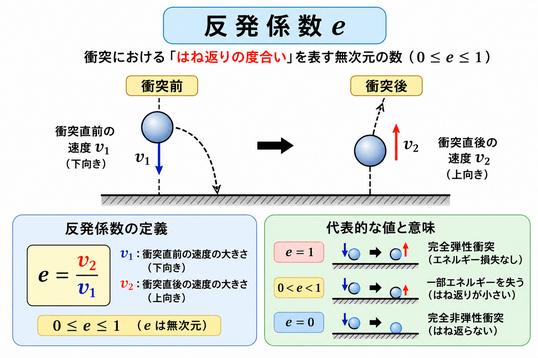

- 工学的なシミュレーションでは，ほとんど使われない．
    - 運動方程式の解（速度）を，人為的に再代入する必要があり，極めて作為的．
    - 垂直抗力を計算しないので，摩擦の計算も不可能．
    - 現実の床材は変形する．それに伴う反発係数は，床材の弾性と減衰特性で決まる．それを表せない．
- 反発係数に相当する性質は，床の減衰係数 $C$ で表す．

## §６ 研究課題

> #### **実習３**
> 1. 自分なりに実現したい壁や床を構想し，具体的な配置をノートにスケッチせよ．
> 2. TAの助けを借りながら，プログラミングせよ．